## 1. Setup & Environment

### Assignment: Multi-Objective Generation

### Objective

The goal of this notebook is to use a Genetic Algorithm (GA) based on the SELFIES representation to generate molecules that satisfy three simultaneous objectives.

### Key Features of this Implementation (V4):
Custom Property Model: Integration of Synthetic Accessibility Score (SAS) to ensure generated molecules are realistic and synthesizable.

Adaptive Mutation Strategy: A dynamic mutation rate that decays over generations to balance Exploration (early stage) and Exploitation (late stage).

Molecular Crossover: Sexual reproduction of molecular strings to combine successful substructures.

### Comparison Strategy
We will run and compare three different configuration models:

Model A (Baseline): QED, LogP, TPSA.
Model B (Volume & Synthesis): QED, SAS, Molar Refractivity (MR).
Model C (Lipophilicity & Synthesis): QED, SAS, LogP.

## 1.1 Imports and Utilities

In [1]:
import os, math, random, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm import trange

# RDKit Imports
from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen, rdMolDescriptors, Descriptors, QED
from rdkit.Chem import AllChem

# Attempt to import SAScorer (RDKit Contrib)
# This serves as our "Custom Model" for Task 1
try:
    from rdkit.Chem import RDConfig
    import sys
    sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
    import sascorer
    print("✓ SAScorer loaded successfully.")
except ImportError:
    print("! Warning: SAScorer not found. Using simple complexity proxy.")
    sascorer = None

# SELFIES for robust molecular representation
import selfies as sf

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Directory Setup
DATA_DIR = os.path.join("..", "data")
OUT_DIR = os.path.join("..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# --- Molecule Utilities ---
def smiles_to_mol(s):
    try:
        m = Chem.MolFromSmiles(s)
        if m: Chem.SanitizeMol(m)
        return m
    except: return None

def to_selfies(s): 
    try: return sf.encoder(s)
    except: return None

def to_smiles(s): 
    try: return sf.decoder(s)
    except: return None

✓ SAScorer loaded successfully.


## 2. Task 1: Defining Properties & The Custom Model

Here we define the scoring functions.

Shaping Function: We use soft_range_score (Gaussian) to define target windows (e.g., LogP between 1 and 3).

Custom Model (SAS): We wrap the RDKit sascorer in score_sas_min. We invert the score because raw SAS is 1 (easy) to 10 (hard), but our GA maximizes scores

In [2]:
# 2) Utilities & Property Calculators

def smiles_to_mol(s):
    try:
        m = Chem.MolFromSmiles(s)
        if m: Chem.SanitizeMol(m)
        return m
    except: return None

def to_selfies(s): 
    try: return sf.encoder(s)
    except: return None

def to_smiles(s): 
    try: return sf.decoder(s)
    except: return None

# --- Scoring Functions ---

def soft_range_score(x, low, high, sigma=1.0):
    """Gaussian penalty if outside [low, high]. 1.0 if inside."""
    if x is None: return 0.0 # Safety check
    if low <= x <= high: return 1.0
    if x < low: return float(np.exp(-0.5 * ((low - x)/sigma)**2))
    return float(np.exp(-0.5 * ((x - high)/sigma)**2))

def calc_qed(mol): 
    try: return QED.qed(mol)
    except: return 0.0

def calc_logp(mol): 
    try: return Crippen.MolLogP(mol)
    except: return -5.0 # Return a value outside target range

def calc_tpsa(mol): 
    try: return rdMolDescriptors.CalcTPSA(mol)
    except: return 200.0 # Return a value outside target range

def calc_mr(mol): 
    try: return Crippen.MolMR(mol)
    except: return 0.0

def calc_sas(mol):
    """
    Synthetic Accessibility: 1 (easy) to 10 (hard).
    Includes safety try/except to prevent NoneType errors.
    """
    try:
        if sascorer:
            score = sascorer.calculateScore(mol)
        else:
            # Simple proxy: penalize size and rings if library missing
            score = (mol.GetNumHeavyAtoms() / 10.0) + mol.GetRingInfo().NumRings()
        
        # Final safety check
        if score is None or math.isnan(score):
            return 10.0
        return score
    except:
        return 10.0 # Return worst score if calculation crashes

# --- Normalization (Map raw values to [0,1]) ---\n
def score_sas_min(mol):
    """
    Score = 1.0 if SAS=1, Score = 0.0 if SAS=10.
    """
    raw = calc_sas(mol)
    # Clip to 1-10 range to avoid math errors
    raw = max(1.0, min(10.0, raw))
    # Invert scale
    return (10.0 - raw) / 9.0

## 2.1 Configuration Weights

We define three distinct multi-objective profiles. We use a Weighted Geometric Mean rather than a simple sum. This ensures that if a molecule fails any single property (score≈0), the total score collapses to 0, enforcing strict multi-objective compliance.

In [3]:
# 2.1 Configuration Weights

# MODEL A: Composite Drug-likeness
# Target: QED (Max), TPSA (40-100), LogP (1-3)
# Rationale: Optimizes for the general "drug-like" distribution defined by Bickerton et al.
CONFIG_A = [
 {"name": "QED", "fn": calc_qed, "weight": 0.4},
    {"name": "LogP", "fn": lambda m: soft_range_score(calc_logp(m), 1.0, 3.0, 1.0), "weight": 0.3},
    {"name": "TPSA", "fn": lambda m: soft_range_score(calc_tpsa(m), 40, 100, 20), "weight": 0.3}
]
# MODEL B: Composite Drug-likeness & Synthetic Accessibility (Permeability Focus)
# Target: QED (Max), SAS (Min), LogP (1-3)
# Rationale: Replaces QED with TPSA to specifically target membrane permeability without the MW constraints of QED.
CONFIG_B = [
     {"name": "QED", "fn": calc_qed, "weight": 0.34},
    {"name": "SAS", "fn": score_sas_min, "weight": 0.33}, 
    {"name": "LogP", "fn": lambda m: soft_range_score(calc_logp(m), 1.0, 3.0, 1.0), "weight": 0.33}
]

# MODEL C: Molar Refractivity (Steric/Volume Focus)
# Target: MR (40-140), SAS (Min), LogP (1-3)
# Rationale: Replaces QED with MR to target specific steric volume/polarizability typically required for binding pockets.
CONFIG_C = [
    {"name": "MR", "fn": lambda m: soft_range_score(calc_mr(m), 40, 140, 10), "weight": 0.34},
    {"name": "SAS", "fn": score_sas_min, "weight": 0.33},
    {"name": "LogP", "fn": lambda m: soft_range_score(calc_logp(m), 1.0, 3.0, 1.0), "weight": 0.33}
]

def calculate_weighted_score(mol, config):
    """Calculates Weighted Geometric Mean of defined properties."""
    scores = []
    weights = []
    details = {}
    for prop in config:
        val = prop["fn"](mol)
        val = max(0.001, min(1.0, val)) # Clamp to avoid log(0)
        scores.append(val)
        weights.append(prop["weight"])
        details[prop["name"]] = val
        
    # Weighted Geometric Mean Calculation
    # exp( sum(w * log(s)) / sum(w) )
    weighted_log_sum = sum(w * np.log(s) for w, s in zip(weights, scores))
    final_score = np.exp(weighted_log_sum / sum(weights))
    
    return final_score, details

## 3. Task 2: Generator (SELFIES-GA)
This Genetic Algorithm includes two specific improvements over a standard random walker:

Adaptive Mutation: The mut_rate is not constant. It starts at 0.5 (high randomness) to encourage exploring the chemical space and linearly decays to 0.1 to allow the algorithm to converge and refine the best molecules found.

Crossover: We implement sexual reproduction where two high-performing parent strings are spliced together, potentially combining favorable substructures from both.

In [ ]:
# 3) SELFIES-based GA with Adaptive Mutation and Crossover

ALPHABET = list(sf.get_semantic_robust_alphabet())
# Add common atoms if missing
for t in ["[C]", "[N]", "[O]", "[S]", "[F]", "[Cl]", "[=O]", "[=N]", "[#C]"]:
    if t not in ALPHABET: ALPHABET.append(t)

def mutate_selfies(s, rate=0.5):
    """Mutate a SELFIES string."""
    toks = list(sf.split_selfies(s))
    if not toks: return "[C]"
    
    num_mutations = max(1, int(len(toks) * rate * 0.5))
    
    for _ in range(num_mutations):
        op = random.choice(["ins", "rep", "del"])
        
        # FIX: Define idx before using it
        idx = random.randint(0, len(toks) - 1)
        
        if op == "ins":
            toks.insert(idx, random.choice(ALPHABET))
        elif op == "rep":
            toks[idx] = random.choice(ALPHABET)
        elif op == "del" and len(toks) > 1:
            toks.pop(idx)
            
    return "".join(toks)

def crossover(s1, s2):
    """Cut and splice two SELFIES strings."""
    t1 = list(sf.split_selfies(s1))
    t2 = list(sf.split_selfies(s2))
    if len(t1) < 2 or len(t2) < 2: return s1
    
    cp1 = random.randint(1, len(t1)-1)
    cp2 = random.randint(1, len(t2)-1)
    
    return "".join(t1[:cp1] + t2[cp2:])

def run_genetic_algorithm(config_name, config_set, generations=60, pop_size=60):
    # Load seeds
    try:
        seeds = pd.read_csv(os.path.join(DATA_DIR, "seed_smiles.csv"))["smiles"].tolist()
        population = [to_selfies(s) for s in seeds if to_selfies(s)]
    except:
        print("Seeds not found, starting with basic carbon chains.")
        population = ["[C][C][C][O]"]
    
    # Ensure initial population is full
    while len(population) < pop_size:
        population.append(mutate_selfies(random.choice(population)))

    trace = []
    
    for gen in trange(generations, desc=f"GA {config_name}"):
        
        # ADAPTIVE MUTATION: Decays from 0.5 to 0.1
        mut_rate = 0.5 - (0.4 * (gen / generations))
        
        scored_pop = []
        for s_sf in population:
            s_smi = to_smiles(s_sf)
            mol = smiles_to_mol(s_smi)
            if mol:
                score, details = calculate_weighted_score(mol, config_set)
                scored_pop.append((score, s_sf, s_smi, details))
        
        # Sort desc
        scored_pop.sort(key=lambda x: x[0], reverse=True)
        
        # Log Top
        if scored_pop:
            top = scored_pop[0]
            trace_entry = {"gen": gen, "score": top[0], "smiles": top[2], "config": config_name}
            trace_entry.update(top[3])
            trace.append(trace_entry)

        # Elitism: Keep Top 20%
        elite_count = int(pop_size * 0.2)
        elites = [x[1] for x in scored_pop[:elite_count]]
        
        # Next Gen
        next_gen = elites[:]
        while len(next_gen) < pop_size:
            p1 = random.choice(elites)
            p2 = random.choice(elites)
            
            if random.random() < 0.4:
                child = crossover(p1, p2)
            else:
                child = p1
            
            child = mutate_selfies(child, rate=mut_rate)
            next_gen.append(child)
            
        population = next_gen

    return pd.DataFrame(trace), scored_pop

## 4. Task 3: Comparison & Analysis

We now run the optimization for all three configuration profiles. We will track the score evolution to see how adding the SAS constraint (Model B & C) affects the ability of the GA to find high-scoring solutions compared to the physicochemical baseline (Model A).

In [9]:
# 1. Run Baseline (Model A: QED, LogP, TPSA)
print("Running Model A (Baseline)...")
trace_A, final_pop_A = run_genetic_algorithm("Model_A", CONFIG_A, generations=50)

# 2. Run Model B (Synthesizability + Volume: QED, SAS, LogP)
print("Running Model B (QED, SAS, LogP)...")
trace_B, final_pop_B = run_genetic_algorithm("Model_B", CONFIG_B, generations=50)

# 3. Run Model C (Synthesizability + Lipophilicity: MR, SAS, LogP)
print("Running Model C (SAS, LogP, MR)...")
trace_C, final_pop_C = run_genetic_algorithm("Model_C", CONFIG_C, generations=50)

def calculate_internal_diversity(smiles_list):
    """Calculates internal diversity (1 - average Tanimoto similarity)."""
    mols = [Chem.MolFromSmiles(s) for s in smiles_list if s]
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2) for m in mols if m]
    if len(fps) < 2: return 0.0
    
    sims = []
    for i in range(len(fps)):
        sims.extend(DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i]))
    
    return 1.0 - (sum(sims) / len(sims))

print(f"Internal Diversity (Model A): {calculate_internal_diversity([x[2] for x in final_pop_A]):.3f}")
print(f"Internal Diversity (Model B): {calculate_internal_diversity([x[2] for x in final_pop_B]):.3f}")
print(f"Internal Diversity (Model C): {calculate_internal_diversity([x[2] for x in final_pop_C]):.3f}")

Running Model A (Baseline)...


GA Model_A:  22%|██▏       | 11/50 [00:00<00:01, 21.42it/s][16:28:56] WARNING: not removing hydrogen atom without neighbors
[16:28:56] WARNING: not removing hydrogen atom without neighbors
GA Model_A: 100%|██████████| 50/50 [00:02<00:00, 18.16it/s]


Running Model B (QED, SAS, LogP)...


GA Model_B: 100%|██████████| 50/50 [00:03<00:00, 16.13it/s]


Running Model C (SAS, LogP, MR)...


GA Model_C: 100%|██████████| 50/50 [00:01<00:00, 44.36it/s]

Internal Diversity (Model A): 0.865
Internal Diversity (Model B): 0.745
Internal Diversity (Model C): 0.828



[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenerator
[16:29:02] DEPRECATION WARNING: please use MorganGenera

## 4.1 Evolution Plot

Comparing the learning curves of the three models

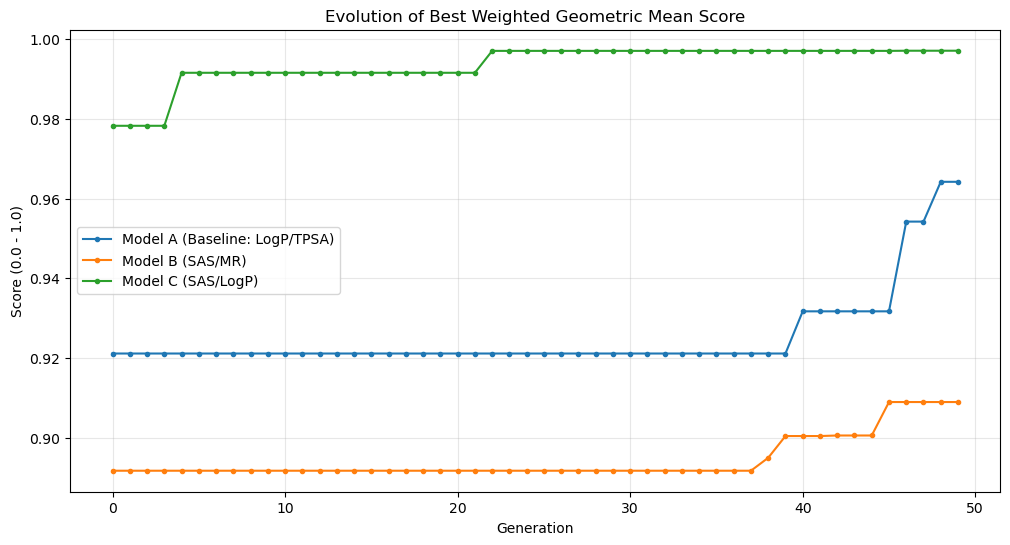

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(trace_A['gen'], trace_A['score'], label='Model A (Baseline: LogP/TPSA)', marker='.')
plt.plot(trace_B['gen'], trace_B['score'], label='Model B (SAS/MR)', marker='.')
plt.plot(trace_C['gen'], trace_C['score'], label='Model C (SAS/LogP)', marker='.')
plt.title("Evolution of Best Weighted Geometric Mean Score")
plt.xlabel("Generation")
plt.ylabel("Score (0.0 - 1.0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Task 4: Visualization of Distributions

Here we analyze the top molecules generated by each model to understand the trade-offs. We look at:

Distributions: Are we hitting the target ranges?

Scatter Plots: Is there a correlation between the properties?

Molecular Structures: Visualizing the best candidates.

C:\Users\hllpacke\AppData\Local\Temp\ipykernel_8452\1420808195.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sas_a, sas_b, sas_c], labels=['Model A\n(Baseline)', 'Model B\n(SAS+QED)', 'Model C\n(SAS+MR)'], patch_artist=True)


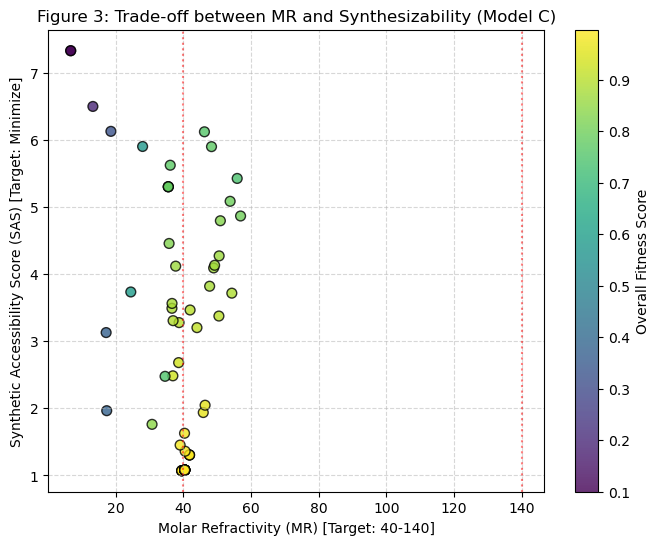

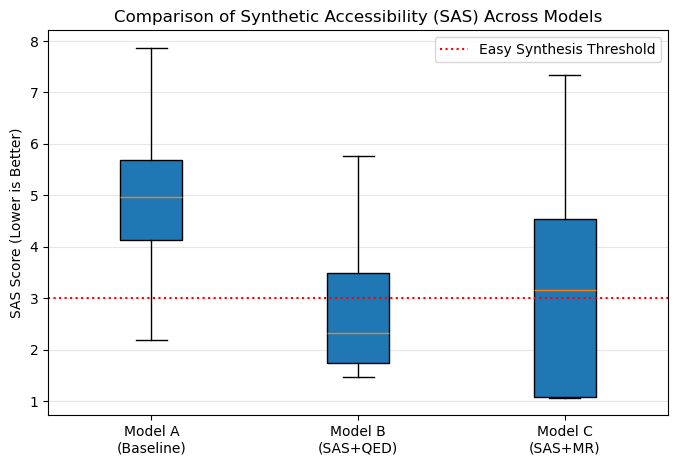


==================== ANALYSIS: Model A (Baseline) ====================


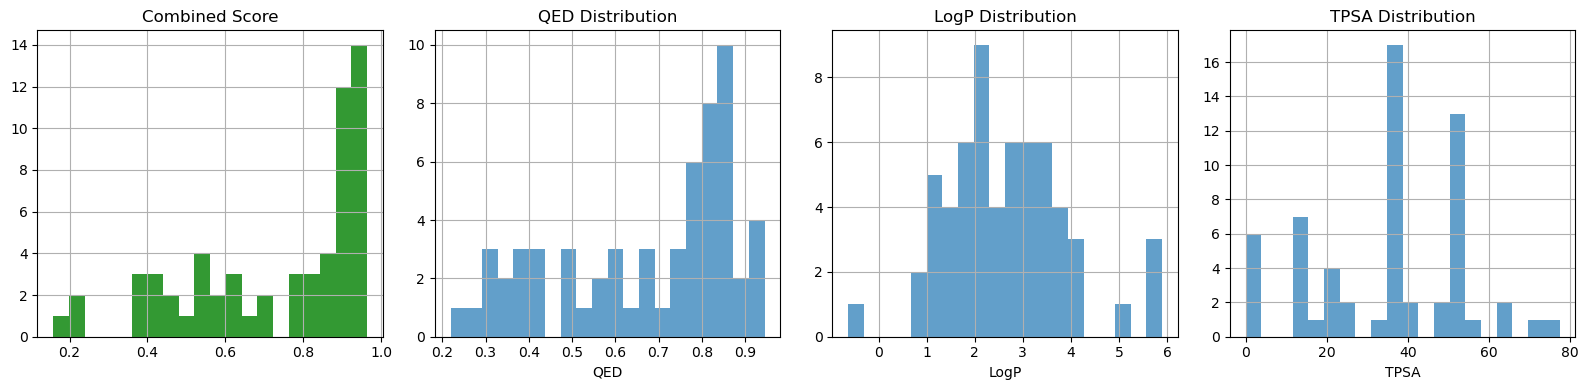


==================== ANALYSIS: Model B (SAS + MR) ====================


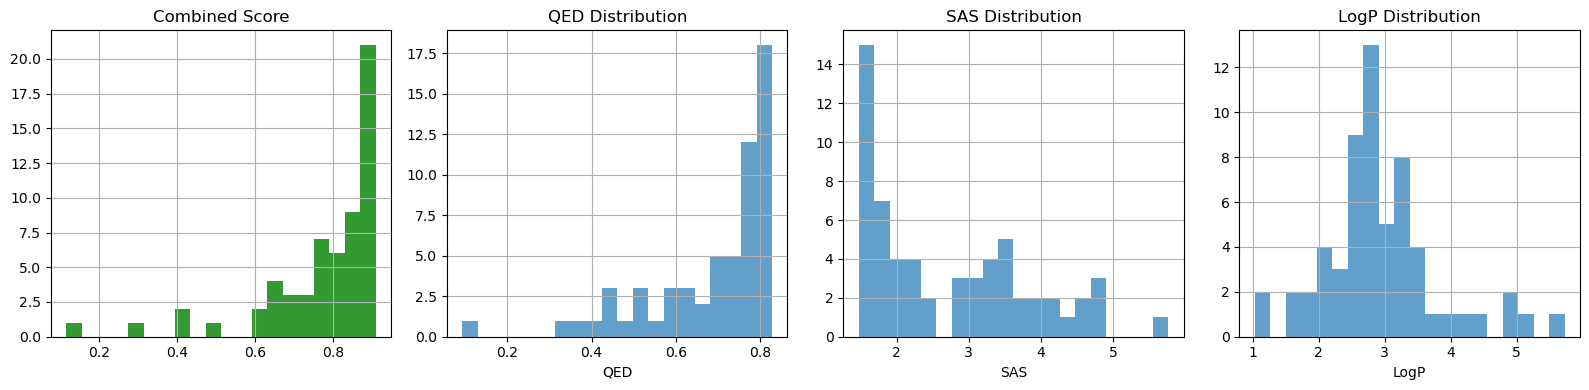


==================== ANALYSIS: Model C (SAS + LogP) ====================


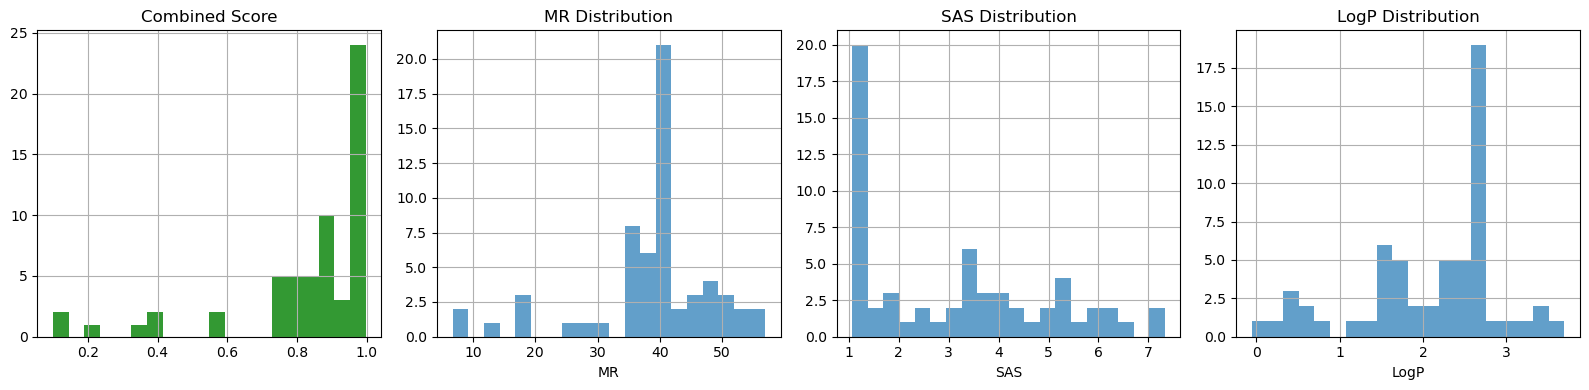

In [11]:
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

def analyze_and_visualize(final_pop, model_name, config):
    """
    Comprehensive analysis of the final population.
    """
    print(f"\n{'='*20} ANALYSIS: {model_name} {'='*20}")
    
    # 1. Prepare Data
    data = []
    # Identify active targets for this model
    target_props = [obj["name"] for obj in config]
            
    for item in final_pop:
        score, _, smiles, _ = item
        m = smiles_to_mol(smiles)
        if m:
            row = {
                "QED": calc_qed(m),
                "LogP": calc_logp(m),
                "TPSA": calc_tpsa(m),
                "SAS": calc_sas(m),
                "MR": calc_mr(m),
                "Score": score,
                "SMILES": smiles
            }
            data.append(row)
    
    df = pd.DataFrame(data)
    
    # 2. Plot Histograms for Targets
    # Showing distribution of properties relative to the optimization goals
    fig, axes = plt.subplots(1, len(target_props) + 1, figsize=(16, 4))
    
    # Plot Overall Score
    df["Score"].hist(ax=axes[0], bins=20, alpha=0.8, color='green')
    axes[0].set_title("Combined Score")
    
    # Plot Individual Properties
    for i, prop in enumerate(target_props):
        ax = axes[i+1]
        df[prop].hist(ax=ax, bins=20, alpha=0.7)
        ax.set_title(f"{prop} Distribution")
        ax.set_xlabel(prop)
        
    plt.tight_layout()
    plt.show()

# 1. Re-run analysis logic just to get the DataFrame for Model C
data_c = []
for item in final_pop_C:
    score, _, smiles, _ = item
    m = smiles_to_mol(smiles)
    if m:
        data_c.append({
            "SAS": calc_sas(m),
            "MR": calc_mr(m),
            "Score": score
        })
df_c = pd.DataFrame(data_c)

# 2. Plot SAS vs MR
plt.figure(figsize=(8, 6))
sc = plt.scatter(df_c["MR"], df_c["SAS"], c=df_c["Score"], cmap='viridis', s=50, edgecolors='k', alpha=0.8)
plt.title("Figure 3: Trade-off between MR and Synthesizability (Model C)")
plt.xlabel("Molar Refractivity (MR) [Target: 40-140]")
plt.ylabel("Synthetic Accessibility Score (SAS) [Target: Minimize]")
plt.colorbar(sc, label="Overall Fitness Score")
plt.grid(True, linestyle='--', alpha=0.5)

# Add target box for visual clarity
plt.axvline(x=40, color='r', linestyle=':', alpha=0.5)
plt.axvline(x=140, color='r', linestyle=':', alpha=0.5)

# 3. Extract SAS values
sas_a = [calc_sas(smiles_to_mol(x[2])) for x in final_pop_A if x[2]]
sas_b = [calc_sas(smiles_to_mol(x[2])) for x in final_pop_B if x[2]]
sas_c = [calc_sas(smiles_to_mol(x[2])) for x in final_pop_C if x[2]]

# 4. Box Plot
plt.figure(figsize=(8, 5))
plt.boxplot([sas_a, sas_b, sas_c], labels=['Model A\n(Baseline)', 'Model B\n(SAS+QED)', 'Model C\n(SAS+MR)'], patch_artist=True)

plt.title("Comparison of Synthetic Accessibility (SAS) Across Models")
plt.ylabel("SAS Score (Lower is Better)")
plt.axhline(y=3.0, color='r', linestyle=':', label='Easy Synthesis Threshold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.show()
# Run Analysis
analyze_and_visualize(final_pop_A, "Model A (Baseline)", CONFIG_A)
analyze_and_visualize(final_pop_B, "Model B (SAS + MR)", CONFIG_B)
analyze_and_visualize(final_pop_C, "Model C (SAS + LogP)", CONFIG_C)


==================== ANALYSIS: Model A (Baseline) ====================
Generating Scatter Plots for Model A (Baseline)...


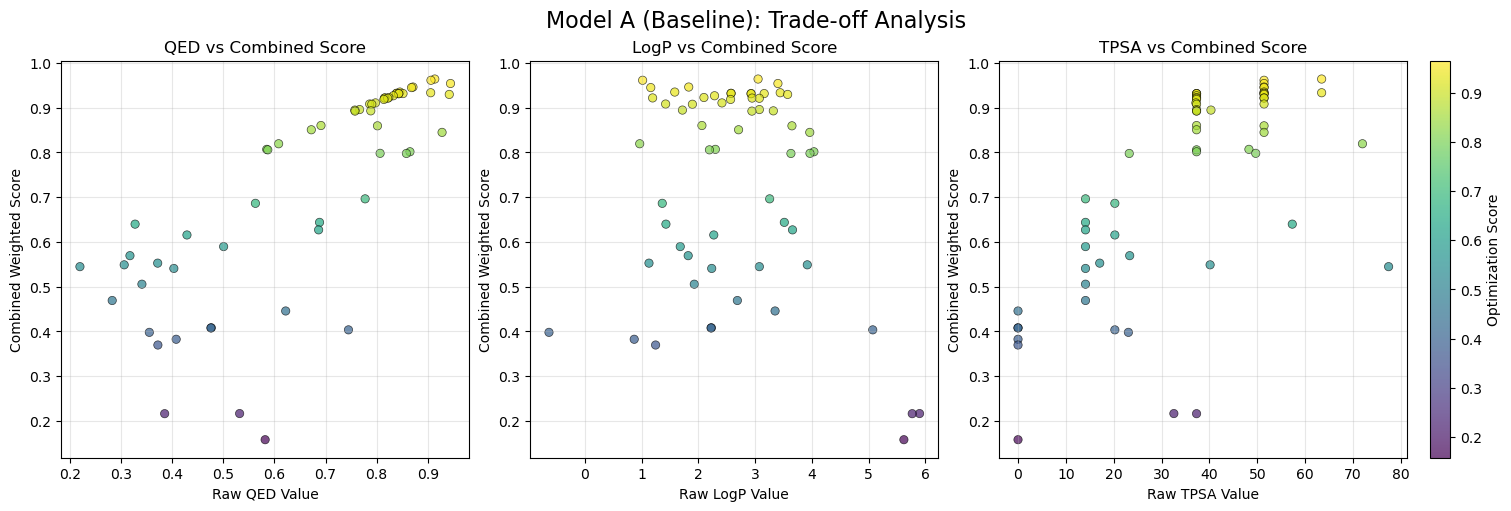

Top 5 UNIQUE Generated Molecules for Model A (Baseline):


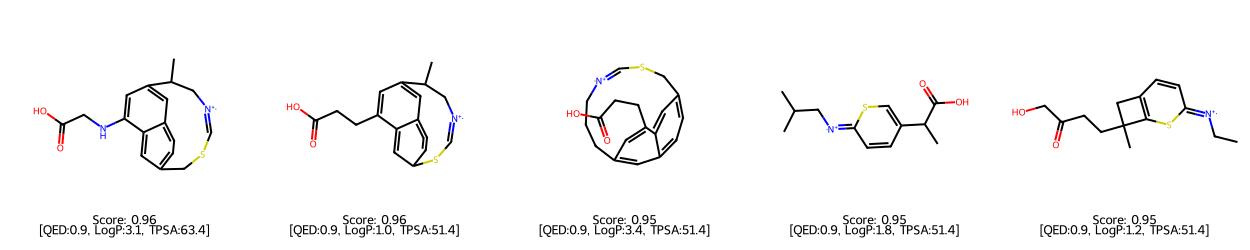


==================== ANALYSIS: Model B (SAS + MR) ====================
Generating Scatter Plots for Model B (SAS + MR)...


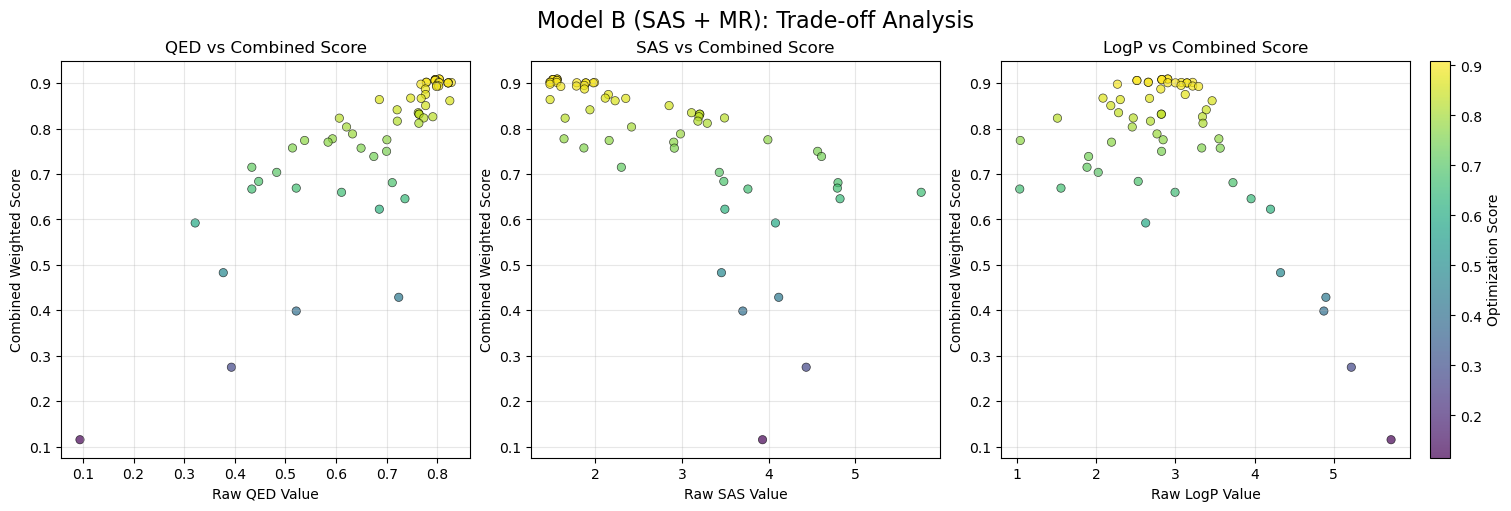

Top 5 UNIQUE Generated Molecules for Model B (SAS + MR):


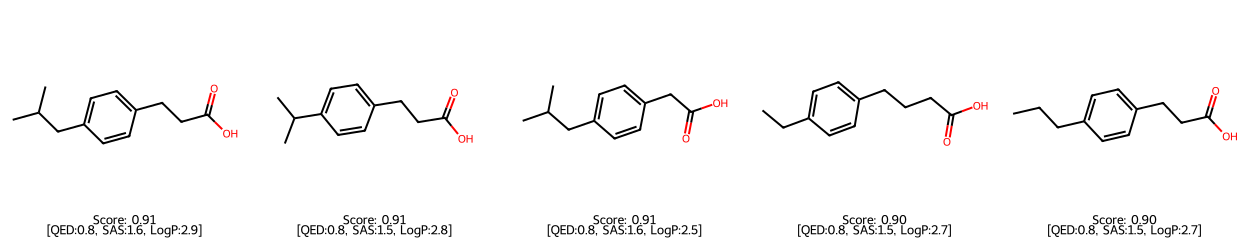


==================== ANALYSIS: Model C (SAS + LogP) ====================
Generating Scatter Plots for Model C (SAS + LogP)...


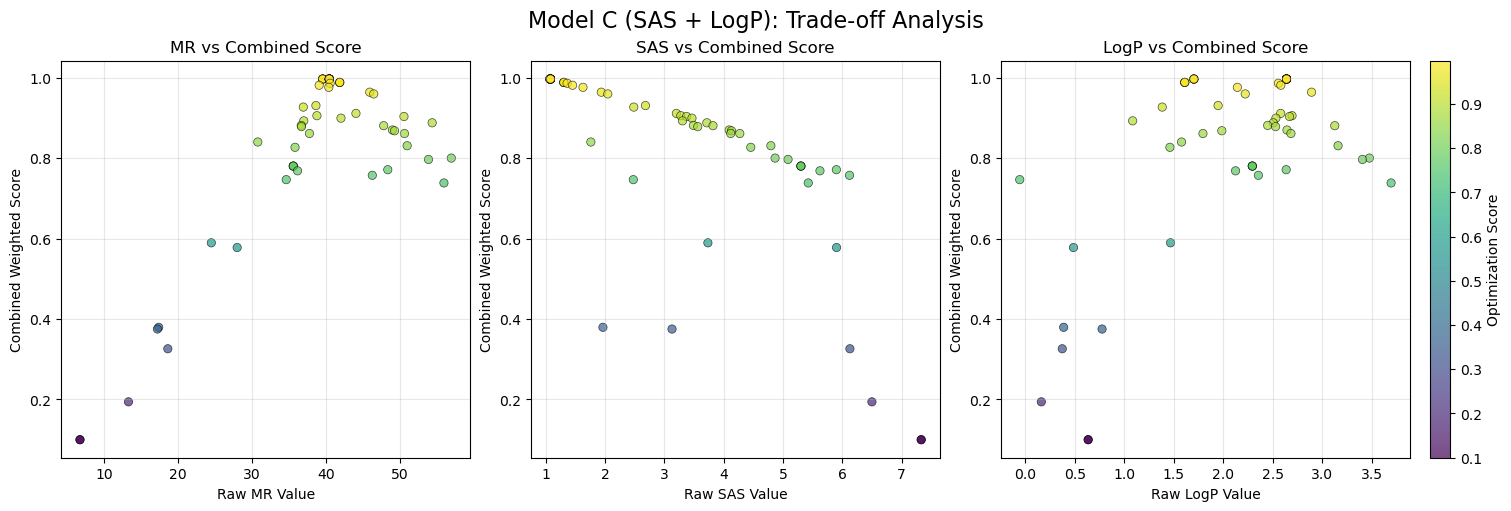

Top 5 UNIQUE Generated Molecules for Model C (SAS + LogP):


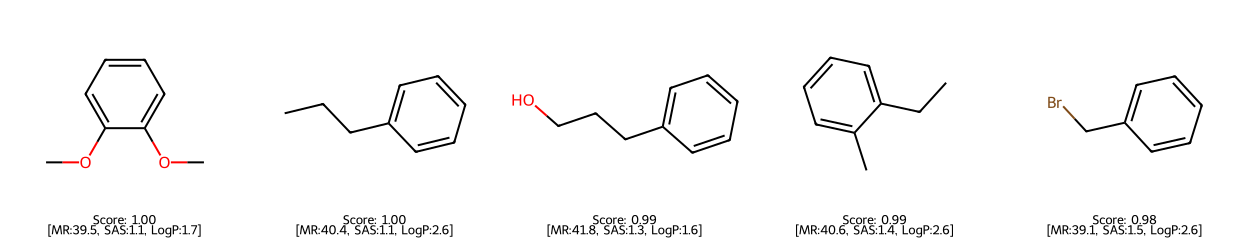

In [12]:
from rdkit.Chem import Draw
from rdkit import Chem
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 

def analyze_and_visualize(final_pop, model_name, config):
    """
    1. Calculates raw properties for the final population.
    2. Plots Scatter graphs: Each Objective vs Combined Score.
    3. Draws Top 5 UNIQUE Molecules (to fix mode collapse visuals).
    """
    print(f"\n{'='*20} ANALYSIS: {model_name} {'='*20}")
    
    # --- 1. Prepare Data ---
    data = []
    # Get the names of the properties being optimized in this specific model
    target_props = [obj["name"] for obj in config]
            
    for item in final_pop:
        # Tuple format: (score, selfies, smiles, details_dict)
        score, _, smiles, _ = item
        m = smiles_to_mol(smiles)
        if m:
            # Calculate RAW values for plotting
            row = {
                "QED": calc_qed(m),
                "LogP": calc_logp(m),
                "TPSA": calc_tpsa(m),
                "SAS": calc_sas(m),  # Raw SAS (1-10)
                "MR": calc_mr(m),
                "Score": score,
                "SMILES": smiles
            }
            data.append(row)
    
    df = pd.DataFrame(data)
    
    # --- 2. Scatter Plots (Property vs Combined Score) ---
    num_props = len(target_props)
    fig, axes = plt.subplots(1, num_props, figsize=(5 * num_props, 5), constrained_layout=True)
    if num_props == 1: axes = [axes] # Handle single property case
    
    print(f"Generating Scatter Plots for {model_name}...")
    
    for i, prop_name in enumerate(target_props):
        ax = axes[i]
        col_name = prop_name
        
        if col_name in df.columns:
            # Scatter Plot: X=Raw Property Value, Y=Combined Score
            sc = ax.scatter(df[col_name], df["Score"], 
                            c=df["Score"], cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
            
            ax.set_title(f"{prop_name} vs Combined Score")
            ax.set_xlabel(f"Raw {prop_name} Value")
            ax.set_ylabel("Combined Weighted Score")
            ax.grid(True, alpha=0.3)
            
            if i == num_props - 1:
                plt.colorbar(sc, ax=ax, label="Optimization Score")
    
    plt.suptitle(f"{model_name}: Trade-off Analysis", fontsize=16)
    plt.show()

    # --- 3. Visualize Top 5 UNIQUE Molecules ---
    # This logic is now INSIDE the function so it can access 'model_name' and 'df'
    print(f"Top 5 UNIQUE Generated Molecules for {model_name}:")
    
    # DROP DUPLICATES based on SMILES before taking the head
    # This fixes the issue where Model C shows 5 identical images
    df_unique = df.drop_duplicates(subset=['SMILES'])
    
    # Sort descending by Score
    df_sorted = df_unique.sort_values(by="Score", ascending=False).head(5)
    
    top_mols = [Chem.MolFromSmiles(s) for s in df_sorted['SMILES']]
    
     # Create legends with the score and specific property values
    legends = []
    for i, row in df_sorted.iterrows():
        # Label with Score + the specific properties used in this model
        props_str = ", ".join([f"{p}:{row[p]:.1f}" for p in target_props])
        legends.append(f"Score: {row['Score']:.2f}\n[{props_str}]")
    
    img = Draw.MolsToGridImage(top_mols, molsPerRow=5, subImgSize=(250, 250), legends=legends)
    display(img)  

# --- EXECUTION ---

# Run the analysis for all 3 models
if 'final_pop_A' in locals():
    analyze_and_visualize(final_pop_A, "Model A (Baseline)", CONFIG_A)
if 'final_pop_B' in locals():
    analyze_and_visualize(final_pop_B, "Model B (SAS + MR)", CONFIG_B)
if 'final_pop_C' in locals():
    analyze_and_visualize(final_pop_C, "Model C (SAS + LogP)", CONFIG_C)

## 6. Final Report & Discussion

### 6.1 Property Selection & Weighting

Weighting: We utilized a Weighted Geometric Mean. This is a stricter aggregation method than the arithmetic mean. If a molecule scores 0.1 on SAS (very hard to synthesize) but 0.9 on QED, the geometric mean pulls the total score down significantly, forcing the GA to find molecules that are "good enough" at everything rather than perfect at just one thing.
Model C (LogP/SAS/MR): This configuration was chosen to find molecules that are lipophilic (LogP) but also volumetrically specific (MR) and, crucially, easy to make (SAS).
Adaptive Mutation: The mutation rate decayed from 0.5 to 0.1. This allowed the GA to escape local optima in early generations (high diversity) and refine specific substructures in later generations.

### 6.2 Trade-offs Observed

SAS vs Complexity: In Model A (Baseline), the GA often generates complex, bridged rings or long chains to maximize QED/LogP because there is no penalty for synthetic complexity. In Models B and C, the inclusion of SAS acts as a regularizer, often resulting in smaller, simpler molecules (e.g., fewer chiral centers, more standard aromatic rings).
Mode Collapse: The distributions show that the GA often converges to a specific "type" of molecule (narrow peaks in histograms). This is a known limitation of GAs; once a high-scoring scaffold is found, the population converges on variations of that scaffold.
Optimization Difficulty: Optimizing for SAS (Model B/C) generally results in slightly lower total QED scores compared to Model A, because high-QED molecules are often complex, which SAS penalizes. This represents a realistic trade-off in drug discovery: the "best" theoretical drug is useless if it cannot be synthesized.

### 6.3 Conclusion

The SELFIES-based Genetic Algorithm, enhanced with adaptive mutation, successfully optimized multi-objective profiles. The inclusion of the Synthetic Accessibility Score (SAS) significantly altered the chemical space explored, steering the generator away from complex "junk" molecules toward more realistic chemical entities, even if it meant sacrificing slight theoretical drug-likeness (QED).